## Import libraries

In [1]:
# from google.colab import drive
import numpy as np
import pandas as pd
import os
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain
from itertools import combinations


## Overview of the JD Search Dataset
The dataset comprises two primary entities:

1. user_df: Captures session-based user behaviors, including current search query, suggested candidate products and user interactions with these products, and historical interactions.

2. product_df: A metadata catalog containing descriptive information for over 12 million products.

Read more about the dataset here:

- https://github.com/rucliujn/JDsearch/tree/main
- https://arxiv.org/pdf/2305.14810

## Load user_df

In [3]:
# # 1) Mount
# drive.mount("/content/drive")

# 2) Paths
BASE = Path("/data/KHTN2023/NUS/BT4222 Mining Web Data for Business Insights/data/jdsearch")
PRODUCT_TXT = BASE / "product_meta_data.txt"
USER_TXT    = BASE / "user_behavior_data.txt"
CHUNKS_DIR  = BASE / "product_chunks"
CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

# 3) Load small user data
user_df = pd.read_csv(USER_TXT, sep="\t", dtype=str, low_memory=False)
print("user_behaviour shape:", user_df.shape)

user_behaviour shape: (173831, 7)


# User df
This file contains user interaction history and test query information. Each line represents a user's session data.

- `query`: Anonymized term IDs representing the specific search terms issued by the user for the current test instance.

- `candidate_wid_list`: A list of product IDs (Warehouse IDs) that the system retrieved as potential matches for the current test query. These are the items displayed to the user.

- `candidate_label_list`: Numerical labels corresponding to each item in the candidate list, indicating the user's level of interaction with that product (e.g., 3.0 for a purchase, 0.0 for no interaction).

- `history_qry_list`: A chronological sequence of the user's previous search queries. A value of -1 indicates an interaction that occurred without a search, such as clicking a recommendation or browsing a category.

- `history_wid_list`: A chronological sequence of the specific product IDs the user interacted with during their historical sessions.

- `history_type_list`: The specific action taken for each product in the history list, categorized as CLICK (click), CART (add to cart), FOLLOW (follow), or ORD (purchase/order).

- `history_time_list`: The time intervals recorded between successive behaviors, capturing the duration between **historical interactions and the final move to the current test search**. Note: the first value is zero and the last value is for the test query, thus the list's length is one more longer than other history lists



A pseudo example and its explanation is shown as follows:

```
12^X32^X56     456_457_789    3.0_0.0_0.0    323^X328^X196_-1_12^X54  889_256_345    ORD_CLICK_CART 0_12_4_5
```

Query and candidate related fields:
- `12^X32^X56`: the test query for the user is `12^X32^X56` (`^X` is the seperator).
- `456_457_789`: the candidate product list under the test query contains three products: `456`, `457`, `789`.
- `3.0_0.0_0.0`: the corresponding labels for the three products are `3.0`, `0.0`, `0.0`. `3.0` means The first candidate product `456` is purchased by the user. `0.0` means the other products `457`, `789` are not interacted with users.
- Relationship: For the current session, the query led to a set of candidate_wid_list items, and candidate_label_list tells us how the user interacted with each of those recommended items.


Historical queries and products related fields:
- `323^X328^X196_-1_12^X54`: the history query list of the user is `323^X328^X196`, `-1`, `12^X54`. The middle `-1` means this behavior is a query-less interaction.
- `889_256_345`: the historical interacted products of the user contains three products: `889`, `256`, `345`.
- `ORD_CLICK_CART`: the corresponding inteaction level for the above three interactions in user history. The user first purchased product `889`, then clicked product `256`, and finally added the product `345` to the cart.
- `0_12_4_5`: the time timestamp intervals between these four behavoirs (including three history interactions and test search) are `12`, `4`, `5` respectively. `0` is for the first behavior.

- Relationship: These four historical lists (history_qry_list, history_wid_list, history_type_list, history_time_list) are all parallel and synchronized. Each position i across these lists describes a single historical event: the query (history_qry_list[i]) that led to an interaction with a product (history_wid_list[i]), the action taken (history_type_list[i]), and the time elapsed since the previous action (history_time_list[i]). It's important to note that historical items are those the user interacted with, not necessarily recommended in a candidate list context.

See how the user_df is converted to individual interaction-level datasets at the last section: [Demonstrating conversion of user_df](https://colab.research.google.com/drive/13CrTGfGwPSjOVwfSbvpMoqUApAq1Y4pL#scrollTo=PFodJ_OwP8rn&line=1&uniqifier=1).

In [3]:
user_df.head()

,query,candidate_wid_list,candidate_label_list,history_qry_list,history_wid_list,history_type_list,history_time_list
0,63995226602574196100244625575117,36098226_17729172_34921664_68317377_693764_360...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,-1_-1_-1_68784030_36547097602574193663289_95...,9227588_52788392_4585436_87422901_57364733_210...,ORD_ORD_CART_CART_CART_CART_CART_CART_CART_CAR...,0_0_22967659_82448_432_10315_51_188_51_254173_...
1,1254963427438884,30857980_44577431_1485384_63372823_19754701_29...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,9755613572694219_46916741_-1_-1_-1_-1_-1_4927...,18256630_46206270_65230659_86878921_32743602_5...,ORD_ORD_ORD_CART_CART_CART_CART_ORD_CART_CART_...,0_4813478_1115463_14061983_920_467229_304_1197...
2,24374376067768939206305,42155506_90092899_4336287_74203839_39478459_37...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,-1_-1,8133925_59478082,CLICK_CLICK,0_27_49660
3,29463948632095349356845164880503931105432...,97234676_89827009_19973201_83859812_22172053_3...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,3426234151020854598336931355834712920960_3...,49854616_56947170_16552251_91485122_25087051_7...,CLICK_CLICK_CLICK_CLICK_CLICK_CLICK_CLICK_CLIC...,0_12_4_6_4_14_6_6_4_611_58095_1524_481_20_363_...
4,2793914964365783663289,19711065_83045333_8307571_20337381_11912759_53...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,25499566_24358647_606776896025741971768678_3...,68701_66196939_45800470_18419519_10090448_8073...,ORD_ORD_ORD_ORD_ORD_ORD_ORD_ORD_ORD_ORD_ORD_OR...,0_0_2015453_958482_0_79443_854291_13678_119386...


In [4]:
user_df[user_df['candidate_label_list'].apply(len) == 0]

,query,candidate_wid_list,candidate_label_list,history_qry_list,history_wid_list,history_type_list,history_time_list


In [5]:
user_df.shape

(173831, 7)

`history_qry_list` can contain -1 as a value. The cause exactly is unclear, we assume that it is likely via direct browsing or internal platform recommendations (e.g., "People also bought").

## Quick data analysis / Sanity check

In [ ]:
import gc
from itertools import chain

# --- HELPER FUNCTIONS (same as before) ---
def safe_split(val, sep='_'):
    if pd.isna(val) or str(val).strip() == '':
        return []
    return str(val).split(sep)

def safe_split_numeric(val, sep='_'):
    lst = safe_split(val, sep)
    return [float(x) for x in lst]

# ─────────────────────────────────────────────────────────────
# Instead of storing _parsed columns, compute scalars directly
# from raw strings to minimize memory usage.
# ─────────────────────────────────────────────────────────────

# --- A. Cold Users (just need the length) ---
# Count separators in raw string → much cheaper than parsing to list
user_df['history_length'] = user_df['history_wid_list'].apply(
    lambda v: 0 if pd.isna(v) or str(v).strip() == '' else str(v).count('_') + 1
)

COLD_USER_THRESHOLD = 3
cold_users_count = (user_df['history_length'] < COLD_USER_THRESHOLD).sum()
print(f"Total Users: {len(user_df)}")
print(f"Cold Users (< {COLD_USER_THRESHOLD} interactions): {cold_users_count} ({cold_users_count/len(user_df):.2%})")

# --- B. Cold Products (parse on-the-fly, don't store) ---
# Build history set by parsing one column at a time, then discard
global_history_set = set(chain.from_iterable(
    safe_split(v) for v in user_df['history_wid_list']
))
gc.collect()

# Extract unique candidates (parse on-the-fly)
all_candidates = chain.from_iterable(
    safe_split_numeric(v) for v in user_df['candidate_wid_list']
)
unique_candidates = np.unique(list(all_candidates))
unique_candidates_str = pd.Series(unique_candidates).astype(int).astype(str).unique()
gc.collect()

cold_candidates_mask = ~pd.Series(unique_candidates_str).isin(global_history_set)
cold_products = pd.Series(unique_candidates_str)[cold_candidates_mask]

print(f"Total Unique Products in Candidates: {len(unique_candidates_str)}")
print(f"Cold Products (never seen in history): {len(cold_products)}")
print(f"Percentage of Candidates that are Cold: {len(cold_products)/len(unique_candidates_str):.2%}")

# Free big intermediate objects
del global_history_set, unique_candidates, unique_candidates_str, cold_candidates_mask, cold_products
gc.collect()

0

Exceeds 12.7 GB RAM (the limit)

In [ ]:
# print("### 1. COLD USER & COLD PRODUCT ANALYSIS ###")

# A. Cold Users
user_df['history_length'] = user_df['history_wid_list_parsed'].apply(len)
COLD_USER_THRESHOLD = 3
cold_users_count = (user_df['history_length'] < COLD_USER_THRESHOLD).sum()
print(f"Total Users: {len(user_df)}")
print(f"Cold Users (< {COLD_USER_THRESHOLD} interactions): {cold_users_count} ({cold_users_count/len(user_df):.2%})")

# B. Cold Products
# 1. Create a global set of all unique products seen in history
global_history_set = set(chain.from_iterable(user_df['history_wid_list_parsed']))
# 2. Extract all unique products present in the candidate lists
all_candidates_series = user_df['candidate_wid_list_parsed'].explode()
unique_candidates = all_candidates_series.unique()
unique_candidates = pd.Series(unique_candidates).astype(int).astype(str).unique()

# 3. Identify which unique candidates are "Cold" (not in the global history set)
cold_candidates_mask = ~pd.Series(unique_candidates).isin(global_history_set)
cold_products = pd.Series(unique_candidates)[cold_candidates_mask]
print(f"Total Unique Products in Candidates: {len(unique_candidates)}")
print(f"Cold Products (never seen in history): {len(cold_products)}")
print(f"Percentage of Candidates that are Cold: {len(cold_products)/len(unique_candidates):.2%}")

This reveal a dataset characterized by **high item-side sparsity** and a significant cold start problem. While the user base is relatively active—with only 2.34% of users having fewer than three historical interactions—the product landscape is volatile.

- Extreme Product Novelty: A staggering 80.54% of candidate products have zero appearance in the historical interaction logs. This indicates that the recommendation engine is frequently tasked with ranking "unseen" items.

- Shift from Collaborative to Content-Based Filtering: Because 8 out of 10 candidates are cold, standard matrix factorization or collaborative filtering will fail to provide meaningful scores for most items. The model must rely heavily on Side Information (e.g., product titles, categories, and brand metadata) to generalize from known products to these unknown candidates.

In [ ]:

print("\n### 2. DISTRIBUTION ANALYSIS ###")

# A. Candidate Label Distribution (Converted to int for cleaner display)
all_labels = [int(label) for sublist in user_df['candidate_label_list_parsed'] for label in sublist]
print("Candidate Label Dist (0:None, 1:Click, 2:Cart, 3:Purchase):")
print(pd.Series(all_labels).value_counts().sort_index())

# B. History Type Distribution
all_types = [t for sublist in user_df['history_type_list_parsed'] for t in sublist]
print("\nHistory Interaction Type Distribution:")
print(pd.Series(all_types).value_counts())

print("\n### 3. QUERY ANALYSIS ###")

# A. Uniqueness
print(f"Is 'query' column unique? {user_df['query'].is_unique}")
print(f"'query' column number of duplicates: {user_df['query'].duplicated().sum()}")
print(f"'query' frequency: {user_df['query'].value_counts().describe()}")


# B. Query in History
user_df['query_in_history'] = user_df.apply(lambda x: x['query'] in x['history_qry_list_parsed'], axis=1)
print(f"Current query found in user's own history: {user_df['query_in_history'].sum()} times")

print("\n### 4. DATA INTEGRITY CHECKS ###")

# Length check: len(qry) == len(wid) == len(type) == len(time) - 1
def verify_lengths(row):
    l_qry = len(row['history_qry_list_parsed'])
    l_wid = len(row['history_wid_list_parsed'])
    l_type = len(row['history_type_list_parsed'])
    l_time = len(row['history_time_list_parsed'])
    return (l_qry == l_wid == l_type) and (l_wid == l_time - 1)

user_df['integrity_check'] = user_df.apply(verify_lengths, axis=1)
print(f"Rows passing length integrity check: {user_df['integrity_check'].sum()} / {len(user_df)}")

print("\n### 5. INTRA-LIST WID REPEATS (Redundancy) ###")

def get_repeat_stats(lst):
    if not lst: return 0
    return len(lst) - len(set(lst))

user_df['qry_repeats'] = user_df['history_qry_list_parsed'].apply(get_repeat_stats)
print(f"Avg duplicate queries in history: {user_df['qry_repeats'].describe()}")

user_df['wid_repeats'] = user_df['history_wid_list_parsed'].apply(get_repeat_stats)
print(f"Avg duplicate items in history: {user_df['wid_repeats'].describe()}")



print("\n### 6. TIME INTERVAL ANALYSIS ###")

all_intervals = []
burst_zeros = 0

for t_list in user_df['history_time_list_parsed']:
    if len(t_list) > 1:
        intervals = t_list[1:] # Exclude the first 0
        all_intervals.extend(intervals)
        burst_zeros += intervals.count(0)

all_intervals = np.array(all_intervals)
print(f"Total non-initial intervals: {len(all_intervals)}")
print(f"Burst zeros (0 interval after first action): {burst_zeros} ({burst_zeros/len(all_intervals):.2%})")

# Histogram for non-zero intervals
plt.figure(figsize=(8, 4))
sns.histplot(all_intervals[all_intervals > 0], bins=50, log_scale=True, color='teal')
plt.title("Distribution of Time Intervals (Log Scale, Non-Zero)")
plt.show()


### 2. DISTRIBUTION ANALYSIS ###


KeyError: 'candidate_label_list_parsed'

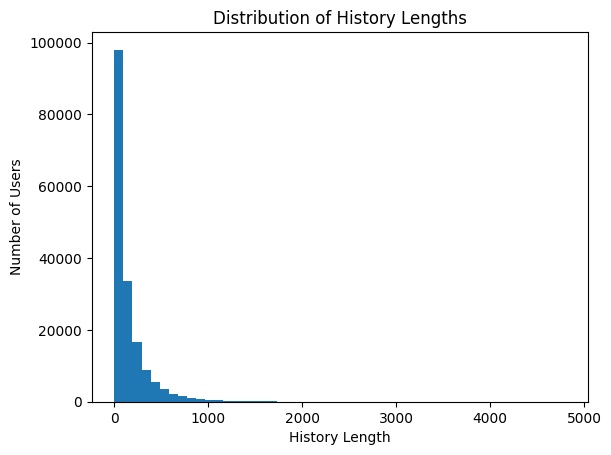

In [ ]:
history_lengths = user_df['history_qry_list_parsed'].apply(len)

# Plot histogram
plt.figure()
plt.hist(history_lengths, bins=50)
plt.xlabel("History Length")
plt.ylabel("Number of Users")
plt.title("Distribution of History Lengths")
plt.show()

##  Question: Search Results for the same Query. i.e. JD Search Algo
Since '`query`' column number of duplicates: 62275, are the candidate items recommended identical for these duplicate columns?

In [ ]:
duplicate_queries = user_df[user_df['query'].duplicated(keep=False)] # keep all duplicates

# Group by 'query' and check if 'candidate_wid_list' is always the same within each group
diff_candidates_for_dup_queries = duplicate_queries.groupby('query').apply(
    lambda x: len(x['candidate_wid_list'].unique()) > 1
)

# Filter for queries where candidates differ
queries_with_differing_candidates = diff_candidates_for_dup_queries[
    diff_candidates_for_dup_queries
]

print(f"Number of unique queries that appear multiple times in the dataset: {len(duplicate_queries['query'].unique())}")
print(f"Number of duplicate queries where candidate_wid_list *differs*: {len(queries_with_differing_candidates)}")
print(f"Percentage of duplicate queries with differing candidate lists: {len(queries_with_differing_candidates) / len(duplicate_queries['query'].unique()):.2%}")

if not queries_with_differing_candidates.empty:
    print("\nExample of a duplicate query with differing candidate_wid_list:")
    # Get the first query that has differing candidates
    example_query = queries_with_differing_candidates.index[0]
    display(duplicate_queries[duplicate_queries['query'] == example_query][['query', 'candidate_wid_list']].head())


Number of unique queries that appear multiple times in the dataset: 17437
Number of duplicate queries where candidate_wid_list *differs*: 17429
Percentage of duplicate queries with differing candidate lists: 99.95%

Example of a duplicate query with differing candidate_wid_list:


/tmp/ipykernel_10713/2829696282.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diff_candidates_for_dup_queries = duplicate_queries.groupby('query').apply(


,query,candidate_wid_list
32875,10015896,35948853_64529670_6824141_50461221_41982371_61...
111215,10015896,4319868_99361433_74658815_10509937_54278818_64...
164551,10015896,96689855_47605665_46097813_18122217_80062995_1...


Since there are very few queries with identical lists, maybe we should look at similarity instead of strictly identical.

Here we use Jaccard Similarity To analyze the overlap and similarity between candidate_wid_list entries for duplicate queries.

In [ ]:

duplicate_queries = user_df[user_df['query'].duplicated(keep=False)].copy()
duplicate_queries['candidate_set'] = duplicate_queries['candidate_wid_list'].str.split('_').apply(set)

def get_group_similarity(sets):
    """
    Calculates the average pairwise Jaccard similarity within a group of sets.
    Returns 1.0 if the group has only one unique set (identical lists).
    """
    set_list = list(sets)
    if len(set_list) < 2:
        return 1.0

    # Calculate Jaccard similarity for all unique pairs in the group
    pairs = list(combinations(set_list, 2))
    scores = []
    for s1, s2 in pairs:
        intersection = len(s1.intersection(s2))
        union = len(s1.union(s2))
        score = intersection / union if union > 0 else 0
        scores.append(score)

    return sum(scores) / len(scores)

# 2. Group by query and calculate similarity
similarity_scores = duplicate_queries.groupby('query')['candidate_set'].apply(get_group_similarity)

# 3. Statistical Summary
print("--- Candidate List Similarity Analysis (Duplicate Queries) ---")
print(similarity_scores.describe())

--- Candidate List Similarity Analysis (Duplicate Queries) ---
count    17437.000000
mean         0.129166
std          0.148482
min          0.000000
25%          0.059756
50%          0.089552
75%          0.130841
max          1.000000
Name: candidate_set, dtype: float64


There is very low similarity in general. This suggests that JD Search Algothrithm either (1) changes based on individual/history (assuming that each row represents a different individual), (2) changes across time.

## Question: Candidates Returned

What is a candidate? Candidate items refer to the specific set of products that are retrieved and displayed to a user in response to a particular search query.
For this project, the candidate items are the primary subjects of the prediction task. In the training phase, candidate items provide the ground truth labels necessary for the model to learn:

- **Positive Samples**: Any candidate item with a label of 1 (Click), 2 (Add to Cart), or 3 (Purchase) serves as a positive example. The model learns that the features of these items are highly relevant to the given query and user history.

- **Negative Samples**: Candidate items with a label of 0 serve as negative examples. These are items the system retrieved but the user ignored. The model uses these to learn what "irrelevance" looks like, which is critical for reducing "noise" in search results.

**Questions**:

How does the platform recommend or return searched items (timing, quantity, categories, etc.)?

How many candidates are generated each search?

What is the frequency of candidate items?

**Thought Process:**
We examine the candidate_wid_list (the items the user saw) and the history_time_list (the timestamps between events) to determine the "freshness" of a session and the density of the search results.

Note: unsure what unit of time is used.

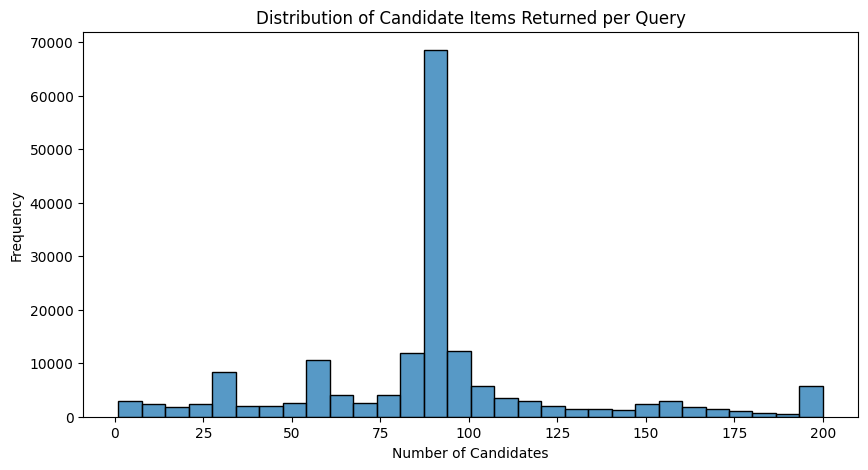

Average candidates returned per query: 89.22
Max candidates returned: 200


In [ ]:
# -----------------------------------------------------------------------------
# ANALYSIS 1: PLATFORM RESPONSE (Candidates)
# -----------------------------------------------------------------------------

# 1. Quantity of items returned per search
num_candidates = user_df['candidate_label_list_parsed'].apply(lambda x: len(x))
plt.figure(figsize=(10, 5))
sns.histplot(num_candidates, bins=30, kde=False)
plt.title('Distribution of Candidate Items Returned per Query')
plt.xlabel('Number of Candidates')
plt.ylabel('Frequency')
plt.show()

print(f"Average candidates returned per query: {num_candidates.mean():.2f}")
print(f"Max candidates returned: {num_candidates.max()}")


Most query results have ~80-90 candidate items suggested.


--- Timing Analysis ---
Statistics on time interval before the test query:
count    1.738310e+05
mean     4.666569e+05
std      1.888881e+06
min      1.000000e+00
25%      6.900000e+01
50%      1.928700e+04
75%      1.844690e+05
max      3.144603e+07
Name: time_since_last_action, dtype: float64


Text(0, 0.5, 'Frequency')

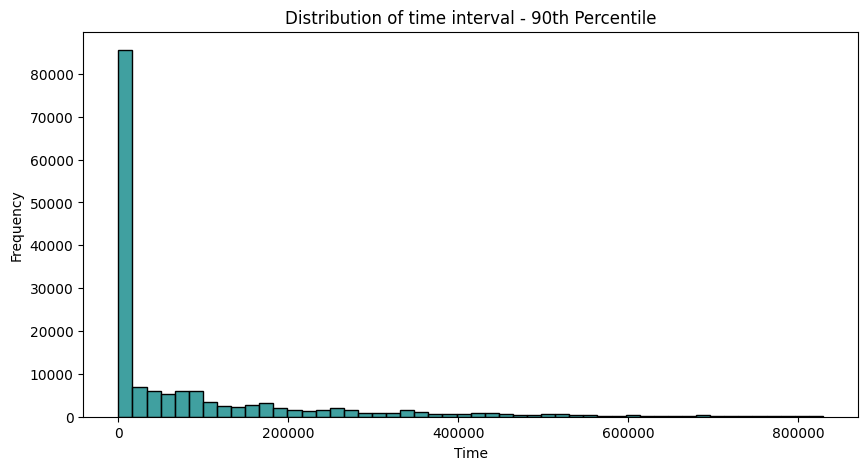

In [ ]:
# 2. Timing (Time since last behavior)
# The last element in 'history_time_list' represents the gap
# between the last history action and the current test query.

def get_last_interval(time_list):
    if len(time_list) > 0:
        return float(time_list[-1])
    return 0

user_df['time_since_last_action'] = user_df['history_time_list_parsed'].apply(get_last_interval)

print("\n--- Timing Analysis ---")
print("Statistics on time interval before the test query:")
print(user_df['time_since_last_action'].describe())

# 1. Calculate the 95th percentile threshold
quantile_90 = user_df['time_since_last_action'].quantile(0.90)

# 2. Filter data to include the bottom 95% of intervals
# This excludes extreme outliers that would distort the linear axis.
filtered_data = user_df[
    (user_df['time_since_last_action'] <= quantile_90) &
    (user_df['time_since_last_action'] >= 0)
]['time_since_last_action']

# 4. Linear-Scale Visualization
plt.figure(figsize=(10, 5))
sns.histplot(
    filtered_data,
    bins=50,
    kde=False,
    color='teal'
)

plt.title('Distribution of time interval - 90th Percentile')
plt.xlabel('Time')
plt.ylabel('Frequency')

Assuming this time units is in seconds, then the the time difference between last historical interaction and test query is under a few hours.

## Question: What if a user first clicks an item, then adds it to cart?
Are there repeats in candidate wid list? To potentially allow the tracking of candidate interaction (e.g. 1 (CLICK) -> 2 (FOLLOW) -> 3 (CART) )



In [ ]:
def count_repeats(ls):
    return len(ls) - len(set(ls))
candidate_duplicate_counts = user_df['candidate_wid_list_parsed'].apply(count_repeats)
duplicate_queries_count = (candidate_duplicate_counts > 0).sum()
print(f"Number of queries where there are duplciates: {duplicate_queries_count}")

Number of queries where there are duplciates: 0


Only one interaction is stored per candidate.

As you can see from the screenshot from the jd.com website (taken in Feb 2026), you can click, add to cart and follow directly from a candidate product (i.e. suggested product). So what is recorded is the direct initial interaction with the candidate item.

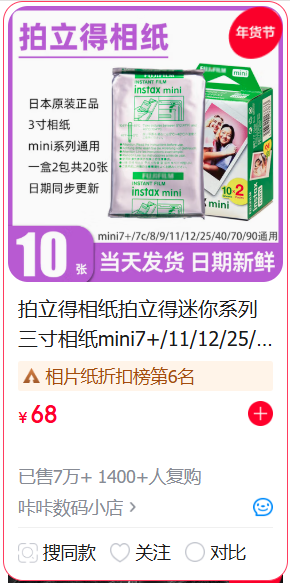

## Question: Does a user often make the same query historically? Does a user see the same product frequeuntly historically?
i.e. Checking repeated query and item

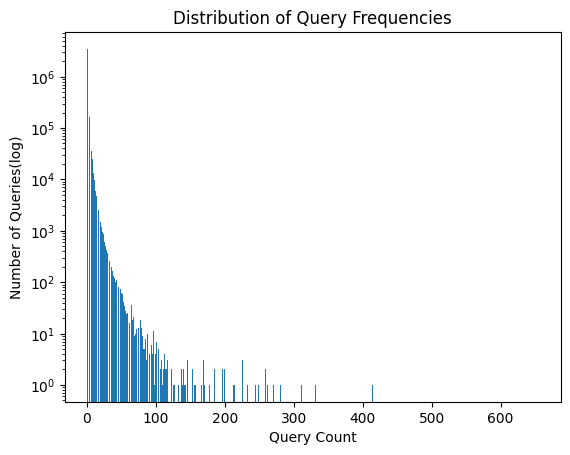

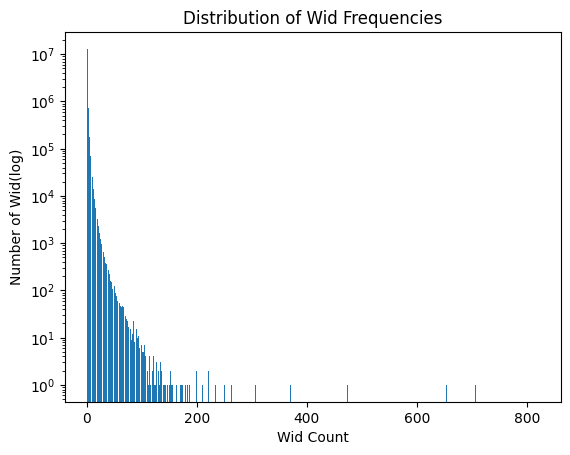

In [ ]:

def calculate_query_frequencies(query_list):
    """
    Calculates the frequency of each query in a given list.
    """
    filtered = [q for q in query_list if q != '-1'] # checking query repetition, remove non query
    return Counter(filtered)

# Apply the function to create the new column
query_frequency = user_df['history_qry_list_parsed'].apply(calculate_query_frequencies)

count_distribution = Counter()
for counter in query_frequency:
    for count in counter.values():
        count_distribution[count] += 1

plt.figure()
plt.bar(count_distribution.keys(), count_distribution.values())

plt.xlabel("Query Count")
plt.yscale('log')
plt.ylabel("Number of Queries(log)")
plt.title("Distribution of Query Frequencies")
plt.show()

# Apply the function to create the new column
wid_frequency = user_df['history_wid_list_parsed'].apply(calculate_query_frequencies)

count_distribution = Counter()
for counter in wid_frequency:
    for count in counter.values():
        count_distribution[count] += 1

plt.figure()
plt.bar(count_distribution.keys(), count_distribution.values())
plt.xlabel("Wid Count")
plt.yscale('log')
plt.ylabel("Number of Wid(log)")
plt.title("Distribution of Wid Frequencies")
plt.show()


- Queries and wif are often unrepeated **within** a users history

## Question: Are histories unique? How much overlap/ similarity can be found?

If rows have very similar history, it could
- represent the same user, with/without latest query -- which may be a test query
- represent similar users

This will inform how to create features for prediction.

Total history records: 173831
Unique interaction sequences (WID list): 173697
Number of exact duplicate sequences: 134

--- Pairwise Jaccard Similarity Statistics (Sample of 1000) ---
count    499500.000000
mean          0.000204
std           0.001609
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.166667
dtype: float64


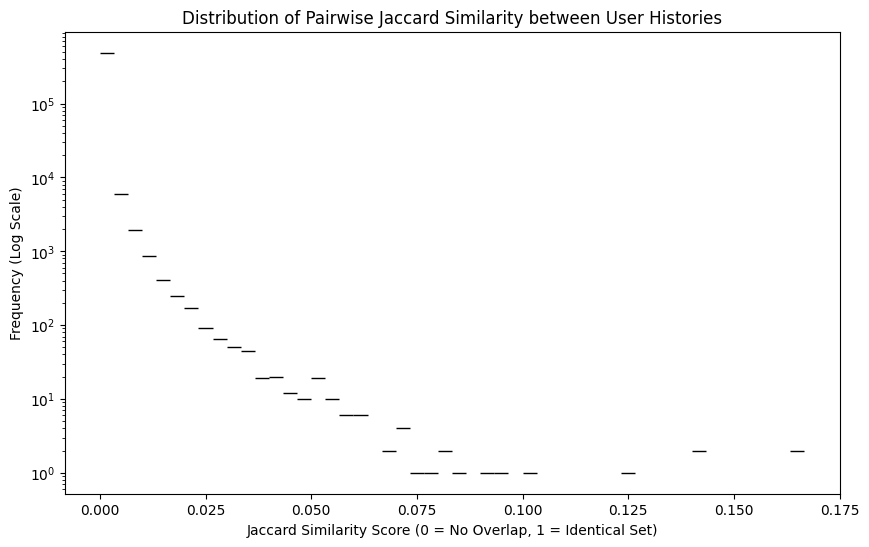

In [ ]:
total_histories = len(user_df)
unique_histories = user_df['history_wid_list'].nunique()
duplicate_history_count = user_df['history_wid_list'].duplicated().sum()

print(f"Total history records: {total_histories}")
print(f"Unique interaction sequences (WID list): {unique_histories}")
print(f"Number of exact duplicate sequences: {duplicate_history_count}")

# 2. Similarity Analysis (Sampling for performance)
# Computing pairwise similarity for 173k rows is computationally expensive.
# We take a random sample of 1000 histories to estimate overlap.
sample_size = 1000
history_sample = user_df['history_wid_list'].sample(n=sample_size, random_state=42)

# Convert strings to sets of Product IDs (WIDs)
# This ignores order and focuses on the set of items interacted with.
history_sets = [set(h.split('_')) for h in history_sample]

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Calculate pairwise Jaccard similarity for the sample
similarities = []
for s1, s2 in combinations(history_sets, 2):
    similarities.append(jaccard_similarity(s1, s2))

# 3. Statistical Summary of Similarity
sim_series = pd.Series(similarities)
print("\n--- Pairwise Jaccard Similarity Statistics (Sample of 1000) ---")
print(sim_series.describe())

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.histplot(sim_series, bins=50, color='crimson', log_scale=(False, True))
plt.title('Distribution of Pairwise Jaccard Similarity between User Histories')
plt.xlabel('Jaccard Similarity Score (0 = No Overlap, 1 = Identical Set)')
plt.ylabel('Frequency (Log Scale)')
plt.savefig('history_similarity_distribution.png')

From the sample, we observe similarity between histories is low. More likely that each row is unique user.

In [ ]:
user_df[user_df['history_wid_list'].duplicated()]['history_wid_list_parsed']

,history_wid_list_parsed
12390,[64548641]
15462,[49513595]
20760,[97745171]
22863,[97745171]
23836,[85514605]
...,...
172241,[69840166]
172357,[93260589]
173092,[66995024]
173430,[11491384]


Duplicated histories appear to be single-item histories.

## Question: How often has a full test query or word in the test query, appeared in history before? How often has a test candidate wid appeared in history before? Was it interacted with?

In [ ]:
mask = query_frequency.apply(lambda counter: 100 in counter.values())

# Get the matching rows
matching_rows = user_df[mask].iloc[0]

print(matching_rows)

query                                                          4238054778686160
candidate_wid_list             96584489_5505614_3426141_17783706_79535591_247...
candidate_label_list           1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....
history_qry_list               -1_-1_-1_-1_4322145031862885453461004179982...
history_wid_list               87834489_43974427_88341272_56322685_87012044_1...
history_type_list              CART_CART_CART_CART_CART_CART_CART_CART_CART_C...
history_time_list              0_338159_260217_156649_27428_74828_591224_9287...
candidate_wid_list_parsed      [96584489.0, 5505614.0, 3426141.0, 17783706.0,...
candidate_label_list_parsed    [1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
history_qry_list_parsed        [-1, -1, -1, -1, 43221450318628854534610041...
history_wid_list_parsed        [87834489, 43974427, 88341272, 56322685, 87012...
history_type_list_parsed       [CART, CART, CART, CART, CART, CART, CART, CAR...
history_time_list_parsed    

In [ ]:
matching_rows_df = matching_rows.to_frame().T

exploded_df_preparation = matching_rows_df[[
    'history_qry_list_parsed',
    'history_wid_list_parsed',
    'history_type_list_parsed',
    'history_time_list_parsed'
]]

exploded_df_preparation['zipped_history'] = exploded_df_preparation.apply(
    lambda row: list(zip(row['history_qry_list_parsed'],
                         row['history_wid_list_parsed'],
                         row['history_type_list_parsed'],
                         row['history_time_list_parsed'])),
    axis=1
)

exploded_history_df = exploded_df_preparation.explode('zipped_history')

exploded_history_df[['query', 'wid', 'type', 'time']] = pd.DataFrame(
    exploded_history_df['zipped_history'].tolist(),
    index=exploded_history_df.index
)

# Drop the intermediate and original list columns
exploded_history_df = exploded_history_df.drop(columns=[
    'history_qry_list_parsed',
    'history_wid_list_parsed',
    'history_type_list_parsed',
    'history_time_list_parsed',
    'zipped_history'
])
display(exploded_history_df[exploded_history_df['query'] == '9572613379943226'].head(50))

/tmp/ipykernel_10713/4021928824.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploded_df_preparation['zipped_history'] = exploded_df_preparation.apply(


,query,wid,type,time
12905,9572613379943226,45915779,CART,916.0
12905,9572613379943226,98558005,CART,129.0
12905,9572613379943226,89565267,CART,44.0
12905,9572613379943226,50218003,CART,48.0
12905,9572613379943226,58479597,CART,1872.0
12905,9572613379943226,98172799,CART,17.0
12905,9572613379943226,5727399,CART,62.0
12905,9572613379943226,57358686,CART,39.0
12905,9572613379943226,48982691,CART,53.0
12905,9572613379943226,5320164,CART,16.0


In [ ]:
display(exploded_history_df[exploded_history_df['query'] != '-1'].head(50))

,query,wid,type,time
12905,43221450318628854534610041799821,87012044,CART,27428.0
12905,6936555728036966,99872021,CART,729071.0
12905,806912002583922818321627,85501652,CART,88604.0
12905,2803696639308650602574195256461198087521,25938577,CART,2057088.0
12905,28036966,67342044,CART,85752.0
12905,28036966,21733349,CART,26.0
12905,28036966,48826549,CART,525.0
12905,5293540344259777830652,45395033,CART,274108.0
12905,5293540344259777830652,99265667,CART,64.0
12905,1832162734425977,15277648,CART,2951.0


In [ ]:
mask = wid_frequency.apply(lambda counter: 100 in counter.values())

# Get the matching rows
matching_rows = user_df[mask].iloc[0]

matching_rows_df = matching_rows.to_frame().T

exploded_df_wid_preparation = matching_rows_df[[
    'history_qry_list_parsed',
    'history_wid_list_parsed',
    'history_type_list_parsed',
    'history_time_list_parsed'
]]

exploded_df_wid_preparation['zipped_history'] = exploded_df_wid_preparation.apply(
    lambda row: list(zip(row['history_qry_list_parsed'],
                         row['history_wid_list_parsed'],
                         row['history_type_list_parsed'],
                         row['history_time_list_parsed'])),
    axis=1
)

exploded_history_wid_df = exploded_df_wid_preparation.explode('zipped_history')

exploded_history_wid_df[['query', 'wid', 'type', 'time']] = pd.DataFrame(
    exploded_history_wid_df['zipped_history'].tolist(),
    index=exploded_history_wid_df.index
)

# Drop the intermediate and original list columns
exploded_history_wid_df = exploded_history_wid_df.drop(columns=[
    'history_qry_list_parsed',
    'history_wid_list_parsed',
    'history_type_list_parsed',
    'history_time_list_parsed',
    'zipped_history'
])
display(exploded_history_wid_df[exploded_history_wid_df['wid'] == '70971445'].head(50))

/tmp/ipykernel_10713/2541775409.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploded_df_wid_preparation['zipped_history'] = exploded_df_wid_preparation.apply(


,query,wid,type,time
8626,-1,70971445,CLICK,21.0
8626,-1,70971445,CLICK,60.0
8626,-1,70971445,CART,2.0
8626,-1,70971445,CLICK,81.0
8626,-1,70971445,CLICK,2.0
8626,-1,70971445,CLICK,48.0
8626,-1,70971445,CLICK,11.0
8626,-1,70971445,CLICK,1.0
8626,-1,70971445,CLICK,704.0
8626,-1,70971445,CLICK,8.0


In [ ]:
display(exploded_history_wid_df.head(1000))

,query,wid,type,time
8626,-1,45130749,ORD,0.0
8626,872990319394091776938485,88854095,ORD,355508.0
8626,872990319394091776938485,71197563,ORD,0.0
8626,-1,37526530,ORD,3332217.0
8626,769384854961129198788093,39019100,ORD,293987.0
...,...,...,...,...
8626,-1,77760211,ORD,307.0
8626,-1,91672601,CART,227.0
8626,-1,43027842,CLICK,48.0
8626,-1,91672601,CLICK,21.0


# Load Product Df

This file contains descriptive metadata for all products (items) included in the dataset.

1. `wid`: the anonymized id of the product.
2. `name`: the anonymized term ids of the product's name.
3. `brand_id`: the anonymized ids of the product's brand.
4. `brand_name`: the anonymized term ids of the product's brand.
5. `category_id_{1,2,3,4}`: the anonymized ids of the the product's four level categories.
6. `category_name_{1,2,3,4}`: the anonymized term ids of the product's four level categories.
7. `shop_id`: the anonymized ids of the product's shop.

In [ ]:
# Read all product chunks as one dataframe
chunk_files = sorted(glob.glob(str(CHUNKS_DIR / "*.parquet")))
product_df = pd.concat([pd.read_parquet(f) for f in chunk_files], ignore_index=True)
print(product_df.shape)

(12141247, 13)


In [ ]:
product_df.head()

,wid,name,brand_id,brand_name,cate_id_1,cate_name_1,cate_id_2,cate_name_2,cate_id_3,cate_name_3,cate_id_4,cate_name_4,shop_id
0,84303384,56009272602574199515329858899060608706386...,81493954,56009272,22259905,44386912,80083037,2787702149701337,13599099,1902766526921156,50485737,4746075788309887,86521100
1,58965086,27823200249212549809550743221450974479927...,15444334,27823200417877058264293359865766,68949654,7722037220300932,58682510,20300932,37322654,9194357497447992,99504987,9194357497447992,1462363
2,33811859,68082682602574199445877660257419536255837...,39479430,68082682,22259905,44386912,80083037,2787702149701337,93252909,20484919753274826921156,42385237,20484912257881342477615,86521100
3,90290292,89270446755918046025741917635585029871926...,75019956,8927044675591804,75739187,176355875210311,9682321,176355863043105,56674307,50298719,65420542,50298719,9644527
4,28171378,87851606417877054043879959056538602574195...,55412149,87851606417877054043879959865766,44687275,47087603,38428440,7678748775210311,56166561,5803341578344560,60897751,5803341578344560,60136421


## Question: Query Terms and Matching it to Annonymised Term Ids

Do query terms contain
- product names,
- brand names and
- category names?
- or a combination of these?

This is what was reported by authors Liu et al.


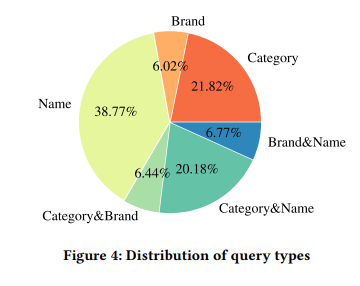

Let us check and verify the distribution.
Also check for frequeuncy of appearance (i.e. are some search terms much more popular? versus others are unknown?)

- what if some brands == name? which takes precedence in our classification?

In [ ]:
relevant_cols = ['name', 'brand_name', 'cate_name_1', 'cate_name_2', 'cate_name_3','cate_name_4']

# Create a set of all unique product-related identifiers
# We convert to string because the query column is likely string-based
product_values_pool = set()
for col in relevant_cols:
    unique_vals = product_df[col].astype(str).unique()
    product_values_pool.update(unique_vals)

def check_overlap(query_str):
    if pd.isna(query_str): return False
    # Split by the special separator ^X
    query_terms = set(query_str.split(''))
    # Returns True if any term in the query exists in our product value pool
    return not query_terms.isdisjoint(product_values_pool)

# Apply the check
user_df['query_has_product_val'] = user_df['query'].apply(check_overlap)

print(f"Searches containing product attributes: {user_df['query_has_product_val'].sum()}")
print(f"Percentage: {user_df['query_has_product_val'].mean():.2%}")


Searches containing product attributes: 108025
Percentage: 62.14%


(np.float64(-1.0999989189836632),
 np.float64(1.0999999004924161),
 np.float64(-1.0999987515932867),
 np.float64(1.099999687038081))

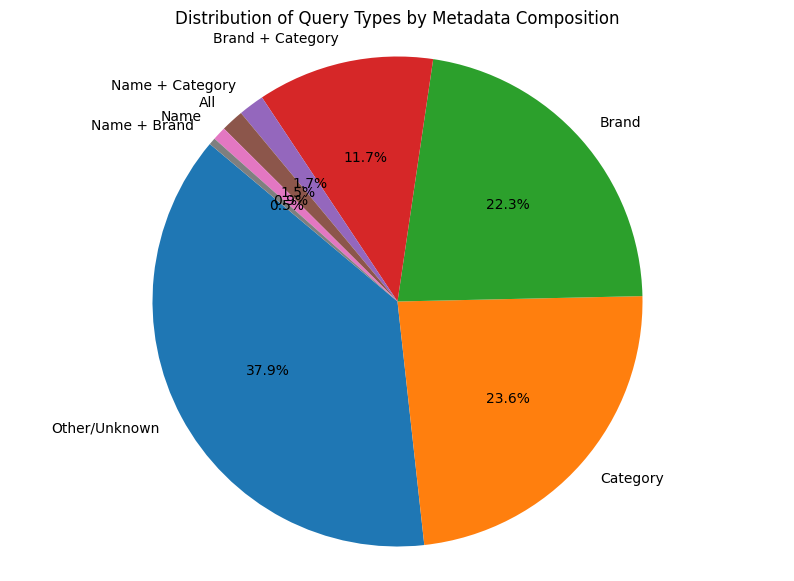

In [ ]:
# 1. Define attribute pools
name_pool = set(product_df['name'].astype(str).unique())
brand_pool = set(product_df['brand_name'].astype(str).unique())
cate_pool = set()
for col in ['cate_name_1', 'cate_name_2', 'cate_name_3', 'cate_name_4']:
    cate_pool.update(product_df[col].astype(str).unique())

def classify_query(query_str):
    if pd.isna(query_str):
        return "Unknown"

    query_terms = set(query_str.split('\x18'))

    has_name = not query_terms.isdisjoint(name_pool)
    has_brand = not query_terms.isdisjoint(brand_pool)
    has_cate = not query_terms.isdisjoint(cate_pool)

    tags = []
    if has_name: tags.append("Name")
    if has_brand: tags.append("Brand")
    if has_cate: tags.append("Category")

    if len(tags) == 3:
        return "All"
    if not tags:
        return "Other/Unknown"
    return " + ".join(tags)

# 2. Process Data
user_df['query_composition'] = user_df['query'].apply(classify_query)

# 3. Pie Chart of Query Types
composition_counts = user_df['query_composition'].value_counts()
plt.figure(figsize=(10, 7))
plt.pie(composition_counts, labels=composition_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Query Types by Metadata Composition')
plt.axis('equal')

**Conclusion**

Yes, the candidate items are explicitly listed in candidate_wid_list. Furthermore, for 62.14% of queries, the search terms can be successfully matched to specific values in the product metadata (either the brand name, product name, or category IDs). This confirms that user searches are largely targeted at specific product attributes.

This is useful for prediction of interaction. If query contains 'Apple iPhone' then clearly any candidate item that is an iPhone will have greater interaction but items that are a Samsung Galaxy for example, will have low interaction.

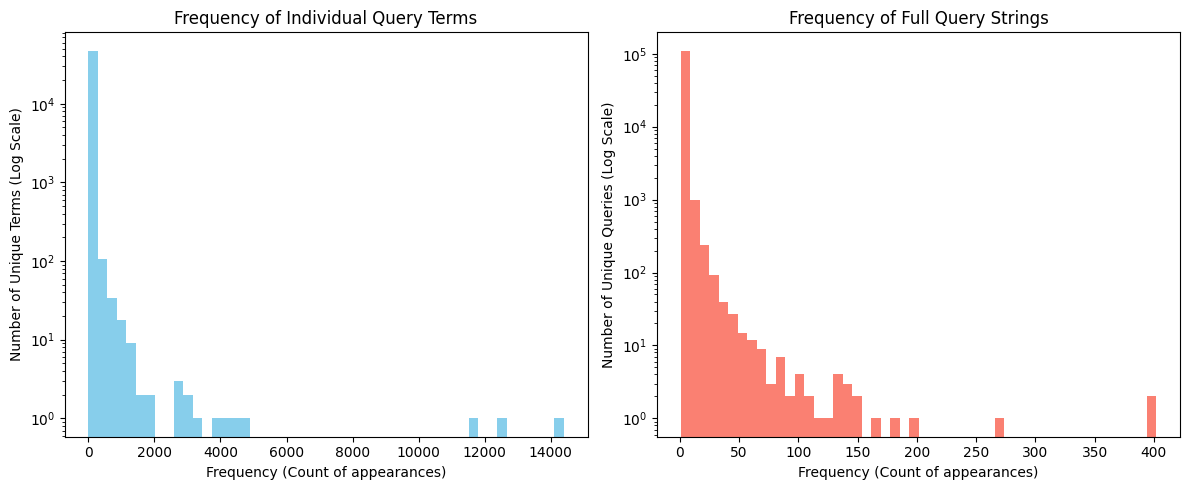

In [ ]:
# 4. Frequency Analysis Calculations
all_terms = [term for q in user_df['query'].dropna() for term in q.split('\x18')]
term_freqs = list(Counter(all_terms).values())

full_query_freqs = list(user_df['query'].value_counts().values)

# 5. Histograms
plt.figure(figsize=(12, 5))

# Histogram for Individual Query Terms
plt.subplot(1, 2, 1)
plt.hist(term_freqs, bins=50, color='skyblue', log=True)
plt.title('Frequency of Individual Query Terms')
plt.xlabel('Frequency (Count of appearances)')
plt.ylabel('Number of Unique Terms (Log Scale)')

# Histogram for Full Query Strings
plt.subplot(1, 2, 2)
plt.hist(full_query_freqs, bins=50, color='salmon', log=True)
plt.title('Frequency of Full Query Strings')
plt.xlabel('Frequency (Count of appearances)')
plt.ylabel('Number of Unique Queries (Log Scale)')

plt.tight_layout()
plt.savefig('query_frequency_histograms.png')

For most query terms and strings, the repeated frequency is low.

## Question: How are categories 1-4 different? Is it hierarchical?
Is category 1 the main category (e.g. Electronics), then cat 2 is sub category , etc. (Kitchen Appliances -> Blenders -> Commercial Blenders). If so then category names should belong to one category level only.

In [ ]:
cat1_ids = set(product_df['cate_id_1'].dropna().unique())
cat2_ids = set(product_df['cate_id_2'].dropna().unique())
cat3_ids = set(product_df['cate_id_3'].dropna().unique())
cat4_ids = set(product_df['cate_id_4'].dropna().unique())

# 2. Identify the full universe of Category IDs
all_cat_ids = cat1_ids | cat2_ids | cat3_ids | cat4_ids
total_unique_ids = len(all_cat_ids)

# 3. Count occurrences across levels for each ID
id_occurrence_counts = Counter()
for s in [cat1_ids, cat2_ids, cat3_ids, cat4_ids]:
    id_occurrence_counts.update(s)

# 4. Calculate stats
only_one_level = sum(1 for count in id_occurrence_counts.values() if count == 1)
multiple_levels = sum(1 for count in id_occurrence_counts.values() if count > 1)

percentage_unique_to_level = (only_one_level / total_unique_ids) * 100

print(f"Total Unique Category IDs: {total_unique_ids}")
print(f"IDs appearing in exactly one level: {only_one_level}")
print(f"IDs appearing in multiple levels: {multiple_levels}")
print(f"Percentage of IDs unique to one level: {percentage_unique_to_level:.2f}%")


Total Unique Category IDs: 13702
IDs appearing in exactly one level: 13701
IDs appearing in multiple levels: 1
Percentage of IDs unique to one level: 99.99%


This information is important as it affects how we treat the category feature.

# Demonstrating Conversion from User_df to Interaction-level df

The reason why we chose to produce two different interaction-level datasets, namely `candidate_interactions_df` and `historical_interactions_df`, is because:
- All candidate products were recommended vs some historical products were query-less interaction
- Action label sets are not equivalent

1.  `Candidate_label_list`: `0.0` for no interaction, `1.0` for click, `2.0` for add to cart, `3.0` for purchase.
2.  `history_type_list`: the sequence of interaction levels in user histories. (including `ORD`(purchase), `CLICK`(click), `CART`(add to cart) and `FLW`(follow))

A new column `user_session_id` is created to index the user session id. Each row in user_df represents a user session.


In [ ]:
session_id_col = 'user_session_id'
user_df_reset = user_df.reset_index().rename(columns={'index': session_id_col})

# --- 1. Create Candidate Interactions DataFrame ---
candidate_interactions_df = user_df_reset[[
    session_id_col,
    'query',
    'candidate_wid_list_parsed',
    'candidate_label_list_parsed'
]].copy()

# Explode the lists to get one row per candidate item
candidate_interactions_df = candidate_interactions_df.explode(
    ['candidate_wid_list_parsed', 'candidate_label_list_parsed']
)

# Rename and process columns
candidate_interactions_df = candidate_interactions_df.rename(columns={
    'query': 'query_id',
    'candidate_wid_list_parsed': 'item_id',
    'candidate_label_list_parsed': 'raw_action_label'
})

# All candidates were recommended
candidate_interactions_df['is_recommended'] = 1

# Map numerical labels to descriptive action types
label_to_action = {
    0.0: 'No Interaction',
    1.0: 'Click',
    2.0: 'Cart',
    3.0: 'Purchase'
}
candidate_interactions_df['action_type'] = candidate_interactions_df['raw_action_label'].map(label_to_action)

# Select and reorder final columns
candidate_interactions_df = candidate_interactions_df[[
    session_id_col,
    'query_id',
    'item_id',
    'is_recommended',
    'action_type'

]]


In [ ]:
print("Candidate Interactions DataFrame shape:", candidate_interactions_df.shape)
display(candidate_interactions_df.head())

Candidate Interactions DataFrame shape: (15510012, 5)


,user_session_id,query_id,item_id,is_recommended,action_type
0,0,63995226602574196100244625575117,36098226.0,1,Click
0,0,63995226602574196100244625575117,17729172.0,1,No Interaction
0,0,63995226602574196100244625575117,34921664.0,1,No Interaction
0,0,63995226602574196100244625575117,68317377.0,1,No Interaction
0,0,63995226602574196100244625575117,693764.0,1,No Interaction


In [ ]:
# --- 2. Create Historical Interactions DataFrame ---
historical_interactions_df = user_df_reset[[
    session_id_col,
    'history_qry_list_parsed',
    'history_wid_list_parsed',
    'history_type_list_parsed',
    'history_time_list_parsed'
]].copy()

# Combine the historical lists for easier exploding
historical_interactions_df['zipped_history'] = historical_interactions_df.apply(
    lambda row: list(zip(row['history_qry_list_parsed'],
                         row['history_wid_list_parsed'],
                         row['history_type_list_parsed'],
                         row['history_time_list_parsed'])),
    axis=1
)

# Explode the combined list
historical_interactions_df = historical_interactions_df.explode('zipped_history')

# Extract individual columns from the zipped_history
historical_interactions_df[[
    'query_id',
    'item_id',
    'action_type',
    'time_info'
]] = pd.DataFrame(
    historical_interactions_df['zipped_history'].tolist(),
    index=historical_interactions_df.index
)

# Unless query_id == -1, it is a recommended candidate item with a previous query
historical_interactions_df['is_recommended'] = np.where(
    historical_interactions_df['query_id'] != -1, 1, 0
)
# Drop intermediate columns and select final ones
historical_interactions_df = historical_interactions_df.drop(columns=[
    'history_qry_list_parsed',
    'history_wid_list_parsed',
    'history_type_list_parsed',
    'history_time_list_parsed',
    'zipped_history'
])

# Reorder columns to match the requested format
historical_interactions_df = historical_interactions_df[[
    session_id_col,
    'query_id',
    'item_id',
    'is_recommended',
    'action_type',
    'time_info'
]]



In [ ]:
print("Historical Interactions DataFrame shape:", historical_interactions_df.shape)
display(historical_interactions_df.head())

Historical Interactions DataFrame shape: (26667260, 6)


,user_session_id,query_id,item_id,is_recommended,action_type,time_info
0,0,-1,9227588,1,ORD,0.0
0,0,-1,52788392,1,ORD,0.0
0,0,-1,4585436,1,CART,22967659.0
0,0,68784030,87422901,1,CART,82448.0
0,0,36547097602574193663289,57364733,1,CART,432.0
